In [15]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import kagglehub
from scipy.stats import t

# 01. Get Data

Path to dataset files: C:\Users\lucas\.cache\kagglehub\datasets\shubham47\salary-data-dataset-for-linear-regression\versions\1


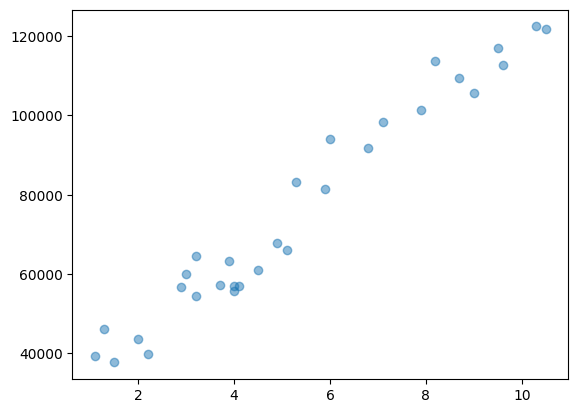

In [3]:
path = kagglehub.dataset_download("shubham47/salary-data-dataset-for-linear-regression")

print("Path to dataset files:", path)

# Download latest version
df = pd.read_csv(os.path.join(path, "Salary_Data.csv"))
df.head()

plt.scatter(df["YearsExperience"], df["Salary"], alpha=0.5)

# 02. Manual Calculations

## 02.01 Definitions

In [4]:
learning_rate = 0.01

# Initial definition of `a` and `b`
a = 0
b = 0

# Calculate predicted values
y_pred = a * df["YearsExperience"] + b

# Calculate residuals
residuals = df["Salary"] - y_pred

In [5]:
# Calculate partial derivatives
def partial_derivative_a(a, x, b, y):
    return 2*a*x**2 + 2*b*x - 2*x*y

def partial_derivative_b(a, x, b, y):
    return 2*a*x + 2*b - 2*y

## 02.02. Manual Iterations

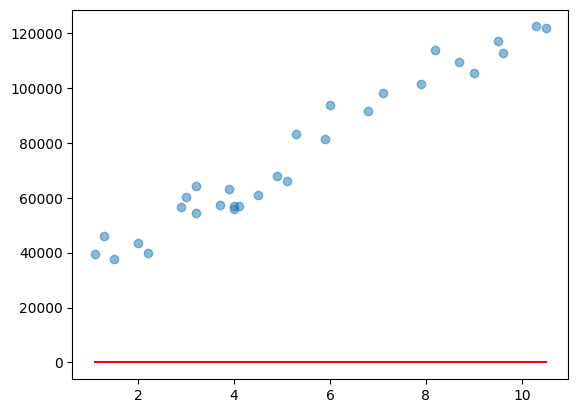

In [6]:
# Visualize line - First iteration
plt.scatter(df["YearsExperience"], df["Salary"], alpha=0.5)
x = np.linspace(df["YearsExperience"].min(), df["YearsExperience"].max(), 100)
y = a * x + b
plt.plot(x, y, color='red')

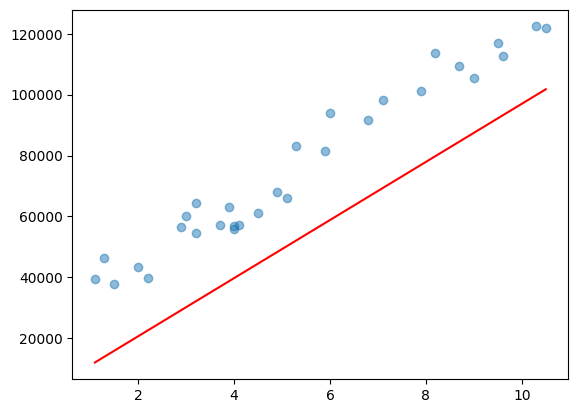

In [7]:
# a / b partial derivatives of sum of squares (ss)
p_d_b = partial_derivative_b(a, df["YearsExperience"], b, df["Salary"]).sum() / len(df)
p_d_a = partial_derivative_a(a, df["YearsExperience"], b, df["Salary"]).sum() / len(df)

# Update `a` and `b`
a = a - learning_rate * p_d_a # Subtract because derivative point to maximization
b = b - learning_rate * p_d_b

# Visualize new line
plt.scatter(df["YearsExperience"], df["Salary"], alpha=0.5)
x = np.linspace(df["YearsExperience"].min(), df["YearsExperience"].max(), 100)
y = a * x + b
plt.plot(x, y, color='red')

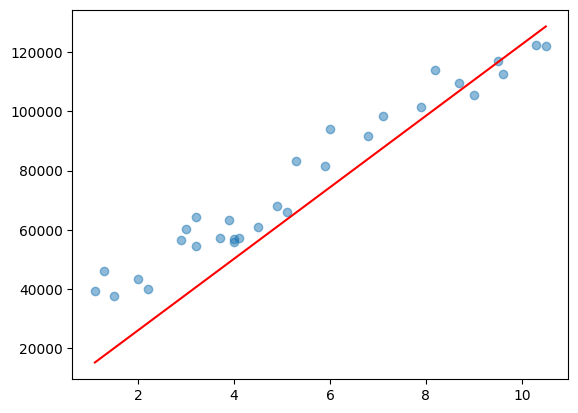

In [8]:
# a / b partial derivatives of sum of squares (ss)
p_d_b = partial_derivative_b(a, df["YearsExperience"], b, df["Salary"]).sum() / len(df)
p_d_a = partial_derivative_a(a, df["YearsExperience"], b, df["Salary"]).sum() / len(df)

# Update `a` and `b`
a = a - learning_rate * p_d_a # Subtract because derivative point to maximization
b = b - learning_rate * p_d_b

# Visualize new line
plt.scatter(df["YearsExperience"], df["Salary"], alpha=0.5)
x = np.linspace(df["YearsExperience"].min(), df["YearsExperience"].max(), 100)
y = a * x + b
plt.plot(x, y, color='red')

# 03. Looping through resolution

In [9]:
a = 0
b = 0

ss = 0
diff = np.inf
max_iter = 20
while max_iter > 0:
    # Calculate predicted values
    y_pred = a * df["YearsExperience"] + b

    diff = (ss - (df["Salary"] - y_pred) ** 2).sum()
    ss = ((df["Salary"] - y_pred) ** 2).sum()

    p_d_b = partial_derivative_b(a, df["YearsExperience"], b, df["Salary"]).sum() / len(df)
    p_d_a = partial_derivative_a(a, df["YearsExperience"], b, df["Salary"]).sum() / len(df)

    # Update `a` and `b`
    a = a - learning_rate * p_d_a
    b = b - learning_rate * p_d_b

    print(f"[EPOCH {20 - max_iter}] SS:", int(ss), "Diff:", int(diff))
    max_iter -= 1

[EPOCH 0] SS: 195088658122 Diff: -195088658122
[EPOCH 1] SS: 17864201560 Diff: 5834795542099
[EPOCH 2] SS: 5493239783 Diff: 530432807039
[EPOCH 3] SS: 4603198294 Diff: 160193995207
[EPOCH 4] SS: 4512948290 Diff: 133583000546
[EPOCH 5] SS: 4478635775 Diff: 130909812938
[EPOCH 6] SS: 4448455479 Diff: 129910617795
[EPOCH 7] SS: 4418797595 Diff: 129034866782
[EPOCH 8] SS: 4389408750 Diff: 128174519118
[EPOCH 9] SS: 4360269335 Diff: 127321993194
[EPOCH 10] SS: 4331376035 Diff: 126476704031
[EPOCH 11] SS: 4302726690 Diff: 125638554388
[EPOCH 12] SS: 4274319232 Diff: 124807481470
[EPOCH 13] SS: 4246151620 Diff: 123983425352
[EPOCH 14] SS: 4218221828 Diff: 123166326779
[EPOCH 15] SS: 4190527849 Diff: 122356127007
[EPOCH 16] SS: 4163067691 Diff: 121552767790
[EPOCH 17] SS: 4135839381 Diff: 120756191371
[EPOCH 18] SS: 4108840961 Diff: 119966340484
[EPOCH 19] SS: 4082070489 Diff: 119183158344


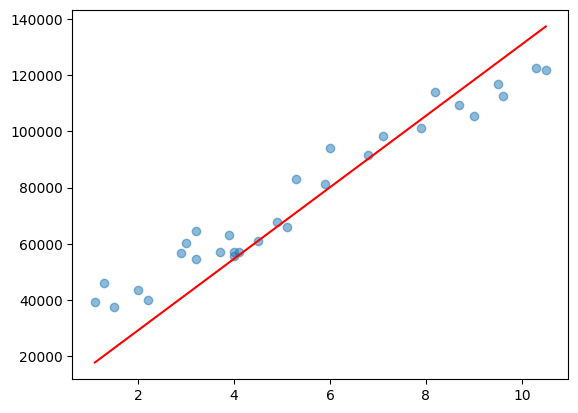

In [10]:
# Visualize line
plt.scatter(df["YearsExperience"], df["Salary"], alpha=0.5)
x = np.linspace(df["YearsExperience"].min(), df["YearsExperience"].max(), 100)
y = a * x + b
plt.plot(x, y, color='red')

# 04. Basic metrics

In [11]:
# How good is my model? (ignoring the fact that I'm testing it on the same data)
RMSE = np.sqrt(ss / len(df))
print(f"RMSE: {RMSE}") # I still can't say for sure if this is good or bad

NRMSE = RMSE / (df["Salary"].max() - df["Salary"].min())
print(f"NRMSE: {NRMSE}") # Calculating the mean %(root squared error) would also be good

RMSE: 11664.862464807391
NRMSE: 0.13778481531782885


In [12]:
# Do my variables help predicting the salary?

# "Predicting" the mean is the way to minimize the error without taking account the experience
mean = df["Salary"].mean()
variance_mean = ((df["Salary"] - mean) ** 2).sum() / len(df)

variance_model = ss / len(df)

# R2 tells me if taking account the experience is better than predicting the mean
r2_score = (variance_mean - variance_model) / variance_mean
print(f"R2 Score: {r2_score}") # 1 is the best score

R2 Score: 0.8127059124626922


In [16]:
# How sure am I about my model? (classical inference for OLS-style coefficients)
# H0: coefficient = 0. Two-tailed p-value from the t-distribution with n - 2 df.

n = len(df)
x = df["YearsExperience"]
y = df["Salary"]
y_pred = a * x + b

ss_res = ((y - y_pred) ** 2).sum()
mse = ss_res / (n - 2)
df_resid = n - 2

x_bar = x.mean()
s_xx = ((x - x_bar) ** 2).sum()

se_a = np.sqrt(mse / s_xx)
se_b = np.sqrt(mse * (1 / n + x_bar**2 / s_xx))

t_a = a / se_a
t_b = b / se_b

p_value_a = 2 * t.sf(abs(t_a), df=df_resid)
p_value_b = 2 * t.sf(abs(t_b), df=df_resid)

print(f"Slope (a):      {a:.2f}")
print(f"  SE:           {se_a:.2f}")
print(f"  t-statistic:  {t_a:.4f}")
print(f"  p-value:      {p_value_a:.6f}")

print(f"\nIntercept (b):  {b:.2f}")
print(f"  SE:           {se_b:.2f}")
print(f"  t-statistic:  {t_b:.4f}")
print(f"  p-value:      {p_value_b:.6f}")

Slope (a):      12703.44
  SE:           787.50
  t-statistic:  16.1314
  p-value:      0.000000

Intercept (b):  3867.88
  SE:           4726.09
  t-statistic:  0.8184
  p-value:      0.420034
